# 지하철 혼잡도 예측 모델 (XGBoost)
서울교통공사 혼잡도 데이터를 학습해 특정 역·시각·방향의 혼잡도를 예측합니다.

**실행 순서:** 셀을 위에서부터 순서대로 실행하세요.

## 0. 라이브러리 설치 및 임포트

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (6,952 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import re

## 1. 데이터 로드

In [ ]:
# ── Google Drive에서 불러오는 경우 ──────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/데이터경로/서울교통공사_지하철혼잡도정보_20260331.csv'

# ── 직접 업로드하는 경우 ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
FILE_PATH = list(uploaded.keys())[0]

df_raw = pd.read_csv(FILE_PATH, encoding='cp949')
print(f'로드 완료: {df_raw.shape[0]}행 × {df_raw.shape[1]}열')
df_raw.head(3)

Saving 서울교통공사_지하철혼잡도정보_20250930.csv to 서울교통공사_지하철혼잡도정보_20250930.csv
Saving 서울교통공사_지하철혼잡도정보_20260331.csv to 서울교통공사_지하철혼잡도정보_20260331.csv
✅ 로드 완료: 1671행 × 44열


,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1호선,150,서울역,상선,8.2,21.8,22.3,39.4,67.2,...,19.7,18.5,18.6,17.1,17.0,17.6,13.0,11.9,6.9,1.1
1,평일,1호선,150,서울역,하선,11.5,11.3,16.9,24.5,40.0,...,40.0,37.9,40.1,36.8,39.2,30.0,18.1,15.9,9.4,0.0
2,평일,1호선,151,시청,상선,7.8,15.1,18.7,31.0,50.8,...,23.7,22.7,23.2,20.1,21.0,20.6,17.2,13.5,7.2,1.0


## 2. Wide → Long 변환

In [ ]:
time_cols = [c for c in df_raw.columns if '시' in c]
print(f'시간대 컬럼 수: {len(time_cols)}개  ({time_cols[0]} ~ {time_cols[-1]})')

df = df_raw.melt(
    id_vars=['요일구분', '호선', '역번호', '출발역', '상하구분'],
    value_vars=time_cols,
    var_name='시간대',
    value_name='혼잡도'
)

df.head(5)

시간대 컬럼 수: 39개  (5시30분 ~ 00시30분)
✅ Long 변환 완료: 65,169행


,요일구분,호선,역번호,출발역,상하구분,시간대,혼잡도
0,평일,1호선,150,서울역,상선,5시30분,8.2
1,평일,1호선,150,서울역,하선,5시30분,11.5
2,평일,1호선,151,시청,상선,5시30분,7.8
3,평일,1호선,151,시청,하선,5시30분,9.7
4,평일,1호선,152,종각,상선,5시30분,7.3


## 3. 피처 엔지니어링

In [ ]:
# ── 시간대 문자열 → 분 단위 정수 ────────────────────────────────────
def parse_time_to_minutes(t):
    """'8시30분' → 510,  '00시00분' → 1440 (자정 이후는 +1440으로 통일)"""
    t = t.strip()
    if '시30분' in t:
        h = int(t.replace('시30분', ''))
        m = 30
    else:
        h = int(t.replace('시00분', ''))
        m = 0
    total = h * 60 + m
    # 00시·00시30분(심야 막차 이후)은 1440·1470으로 보정해 연속성 유지
    if total < 330:  # 5시30분(330분) 미만 = 자정~새벽
        total += 1440
    return total

df['time_minutes'] = df['시간대'].apply(parse_time_to_minutes)

# ── 요일 피처 ────────────────────────────────────────────────────
df['is_weekday']  = (df['요일구분'] == '평일').astype(int)
df['is_saturday'] = (df['요일구분'] == '토요일').astype(int)
# is_sunday = 1 - is_weekday - is_saturday (다중공선성 방지용으로 생략)

# ── 출퇴근 시간대 플래그 ──────────────────────────────────────────
df['is_rush_am'] = ((df['time_minutes'] >= 420) & (df['time_minutes'] <= 540)).astype(int)   # 7~9시
df['is_rush_pm'] = ((df['time_minutes'] >= 1020) & (df['time_minutes'] <= 1140)).astype(int) # 17~19시

# ── 범주형 → 수치 인코딩 ─────────────────────────────────────────
line_cat = pd.CategoricalDtype(sorted(df['호선'].unique()), ordered=False)
dir_cat  = pd.CategoricalDtype(sorted(df['상하구분'].unique()), ordered=False)

df['line_encoded']      = df['호선'].astype(line_cat).cat.codes
df['direction_encoded'] = df['상하구분'].astype(dir_cat).cat.codes
# 역번호는 이미 숫자 → 그대로 사용

# ── 나중에 예측 시 역조회에 쓸 매핑 딕셔너리 저장 ───────────────────
station_to_code = df_raw.drop_duplicates('출발역').set_index('출발역')['역번호'].to_dict()
line_to_enc     = {v: k for k, v in enumerate(sorted(df['호선'].unique()))}
dir_to_enc      = {v: k for k, v in enumerate(sorted(df['상하구분'].unique()))}

print('호선 인코딩:', line_to_enc)
print('방향 인코딩:', dir_to_enc)
print(f'역 수: {len(station_to_code)}개')
print(f'\n피처 생성 완료')
df[['출발역','호선','상하구분','요일구분','시간대','time_minutes',
    'is_weekday','is_rush_am','is_rush_pm','line_encoded','direction_encoded','혼잡도']].head(5)

호선 인코딩: {'1호선': 0, '2호선': 1, '3호선': 2, '4호선': 3, '5호선': 4, '6호선': 5, '7호선': 6, '8호선': 7}
방향 인코딩: {'내선': 0, '상선': 1, '외선': 2, '하선': 3}
역 수: 245개

✅ 피처 생성 완료


,출발역,호선,상하구분,요일구분,시간대,time_minutes,is_weekday,is_rush_am,is_rush_pm,line_encoded,direction_encoded,혼잡도
0,서울역,1호선,상선,평일,5시30분,330,1,0,0,0,1,8.2
1,서울역,1호선,하선,평일,5시30분,330,1,0,0,0,3,11.5
2,시청,1호선,상선,평일,5시30분,330,1,0,0,0,1,7.8
3,시청,1호선,하선,평일,5시30분,330,1,0,0,0,3,9.7
4,종각,1호선,상선,평일,5시30분,330,1,0,0,0,1,7.3


## 4. 데이터 품질 확인

=== 혼잡도 기초 통계 ===
count    65169.00
mean        28.35
std         20.87
min          0.00
25%         12.80
50%         25.00
75%         39.40
max        164.30
Name: 혼잡도, dtype: float64

혼잡도 0인 행: 3,693개 (5.7%) → 제거 예정


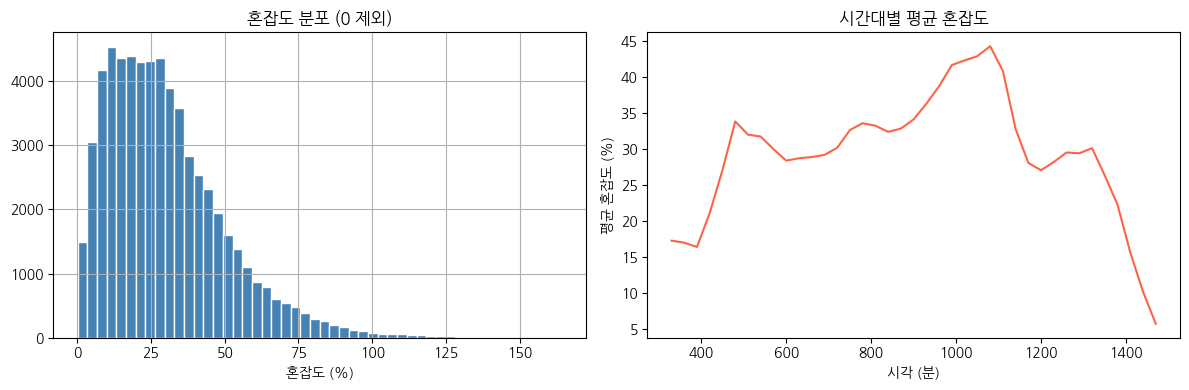

In [ ]:
print('=== 혼잡도 기초 통계 ===')
print(df['혼잡도'].describe().round(2))

# 혼잡도 0인 행 = 운행 없는 시간대 → 학습에서 제외
zero_cnt = (df['혼잡도'] == 0).sum()
print(f'\n혼잡도 0인 행: {zero_cnt:,}개 ({zero_cnt/len(df)*100:.1f}%) → 제거 예정')

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['혼잡도'] > 0]['혼잡도'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('혼잡도 분포 (0 제외)')
axes[0].set_xlabel('혼잡도 (%)')

df[df['혼잡도'] > 0].groupby('time_minutes')['혼잡도'].mean().plot(ax=axes[1], color='tomato')
axes[1].set_title('시간대별 평균 혼잡도')
axes[1].set_xlabel('시각 (분)')
axes[1].set_ylabel('평균 혼잡도 (%)')
plt.tight_layout()
plt.show()

## 5. 학습/테스트 데이터 분할

In [ ]:
# 혼잡도 0 제거 (운행 없는 시간대는 예측 불필요)
df_model = df[df['혼잡도'] > 0].copy()
print(f'학습 데이터: {len(df_model):,}행')

FEATURES = [
    'line_encoded',       # 호선
    '역번호',              # 역 고유 번호
    'direction_encoded',  # 상선/하선/내선/외선
    'time_minutes',       # 시각(분)
    'is_weekday',         # 평일 여부
    'is_saturday',        # 토요일 여부
    'is_rush_am',         # 오전 출근 시간대
    'is_rush_pm',         # 오후 퇴근 시간대
]
TARGET = '혼잡도'

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'학습: {len(X_train):,}행 / 테스트: {len(X_test):,}행')

학습 데이터: 61,476행
학습: 49,180행 / 테스트: 12,296행


## 6. XGBoost 모델 학습

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from itertools import product

param_grid = {
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':     [0.03, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'min_child_weight':  [1, 5, 10],
}

keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'총 조합 수: {len(combos)}개')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for combo in combos:
    params = dict(zip(keys, combo))
    fold_maes, fold_r2s, fold_iters = [], [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(
            **params,
            n_estimators   = 500,
            device         = 'cpu',
            random_state   = 42,
            eval_metric    = 'mae',
            early_stopping_rounds = 30,
        )
        model.fit(
            X_tr, y_tr,
            eval_set = [(X_val, y_val)],
            verbose  = False,
        )

        y_pred = model.predict(X_val)
        fold_maes.append(mean_absolute_error(y_val, y_pred))
        fold_r2s.append(r2_score(y_val, y_pred))
        fold_iters.append(model.best_iteration)

    results.append({
        **params,
        'mean_mae':  np.mean(fold_maes),
        'std_mae':   np.std(fold_maes),
        'mean_r2':   np.mean(fold_r2s),
        'std_r2':    np.std(fold_r2s),
        'mean_iter': int(np.mean(fold_iters)),
    })
    print(f'{params}  →  MAE={np.mean(fold_maes):.3f} (±{np.std(fold_maes):.3f})  '
          f'R²={np.mean(fold_r2s):.4f} (±{np.std(fold_r2s):.4f})')

results_df = pd.DataFrame(results)
results_df.head(10)

총 조합 수: 324개
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 1}  →  MAE=9.218 (±0.054)  R²=0.5955 (±0.0022)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 5}  →  MAE=9.218 (±0.054)  R²=0.5955 (±0.0022)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 10}  →  MAE=9.217 (±0.054)  R²=0.5956 (±0.0023)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 1}  →  MAE=9.157 (±0.057)  R²=0.5998 (±0.0018)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 5}  →  MAE=9.157 (±0.057)  R²=0.5998 (±0.0018)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 10}  →  MAE=9.158 (±0.058)  R²=0.5997 (±0.0018)
{'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 1.0, 'm

KeyboardInterrupt: 

In [ ]:
model = XGBRegressor(
    n_estimators      = 500,   # 트리 수 (early stopping으로 자동 조정됨)
    max_depth         = 10,     # 트리 깊이
    learning_rate     = 0.2,  # 낮을수록 정확하지만 느림
    subsample         = 1.0,   # 행 샘플링 비율
    colsample_bytree  = 1.0,   # 피처 샘플링 비율
    min_child_weight  = 4,     # 과적합 방지
    random_state      = 42,
    eval_metric       = 'mae',
    early_stopping_rounds = 30,
    device = 'cuda' if __import__('os').path.exists('/usr/bin/nvidia-smi') else 'cpu',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f'\n 최적 트리 수: {model.best_iteration}')

[0]	validation_0-mae:13.71111
[50]	validation_0-mae:3.14891
[100]	validation_0-mae:2.58513
[150]	validation_0-mae:2.36836
[200]	validation_0-mae:2.27384
[250]	validation_0-mae:2.19597
[300]	validation_0-mae:2.15926
[350]	validation_0-mae:2.12907
[400]	validation_0-mae:2.10520
[450]	validation_0-mae:2.08425
[499]	validation_0-mae:2.06953

✅ 학습 완료  |  최적 트리 수: 499


## 7. 모델 성능 평가

MAE  : 2.07% 포인트  (예측이 평균 ±2.1% 오차)
R²   : 0.9704          (1.0에 가까울수록 좋음)


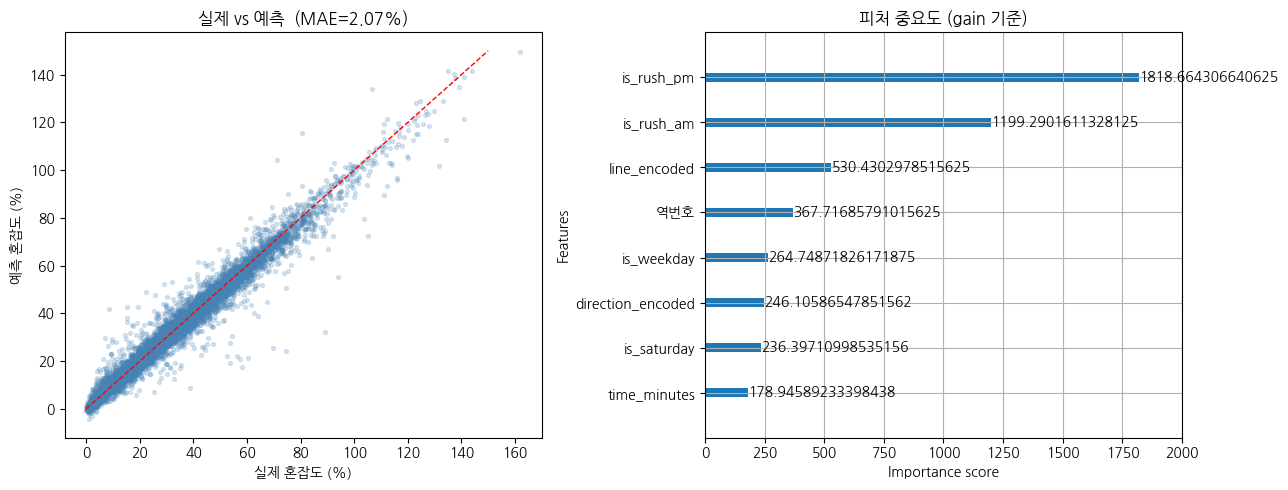

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'MAE  : {mae:.2f}% 포인트  (예측이 평균 ±{mae:.1f}% 오차)')
print(f'R²   : {r2:.4f}          (1.0에 가까울수록 좋음)')

# 실제 vs 예측 산점도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, 150], [0, 150], 'r--', lw=1)
axes[0].set_xlabel('실제 혼잡도 (%)')
axes[0].set_ylabel('예측 혼잡도 (%)')
axes[0].set_title(f'실제 vs 예측  (MAE={mae:.2f}%)')

from xgboost import plot_importance
plot_importance(model, ax=axes[1], max_num_features=8,
                importance_type='gain', title='피처 중요도 (gain 기준)')
plt.tight_layout()
plt.show()

## 8. 모델 & 매핑 딕셔너리 저장

In [ ]:
# 모델 저장
model.save_model('congestion_model.json')

# 예측 시 필요한 매핑 딕셔너리 저장
mappings = {
    'station_to_code': station_to_code,  # 역이름 → 역번호
    'line_to_enc':     line_to_enc,      # 호선명 → 인코딩 번호
    'dir_to_enc':      dir_to_enc,       # 방향명 → 인코딩 번호
    'features':        FEATURES,         # 피처 순서 고정
}
with open('congestion_mappings.json', 'w', encoding='utf-8') as f:
    json.dump(mappings, f, ensure_ascii=False, indent=2)

print('  · congestion_model.json      ← XGBoost 모델')
print('  · congestion_mappings.json   ← 역이름/호선/방향 매핑')

# Google Drive에도 저장하려면:
# !cp congestion_model.json    /content/drive/MyDrive/
# !cp congestion_mappings.json /content/drive/MyDrive/

✅ 저장 완료
  · congestion_model.json      ← XGBoost 모델
  · congestion_mappings.json   ← 역이름/호선/방향 매핑


## 9. 예측 함수 (TMAP 연동용)

In [ ]:
def load_predictor(model_path='congestion_model.json',
                   mappings_path='congestion_mappings.json'):
    """저장된 모델과 매핑을 불러와 예측 함수를 반환합니다."""
    m = XGBRegressor()
    m.load_model(model_path)
    with open(mappings_path, encoding='utf-8') as f:
        mp = json.load(f)
    return m, mp


def predict_congestion(station_name, line, direction,
                       depart_hour, depart_minute, is_weekday,
                       model, mappings):
    """
    단일 역·시각의 혼잡도를 예측합니다.

    Parameters
    ----------
    station_name  : str  예) '서울역'
    line          : str  예) '1호선'
    direction     : str  예) '상선' / '하선' / '내선' / '외선'
    depart_hour   : int  예) 8
    depart_minute : int  예) 30
    is_weekday    : int  1=평일, 0=주말

    Returns
    -------
    float : 예측 혼잡도 (%), None = 매핑 실패
    """
    station_code = mappings['station_to_code'].get(station_name)
    line_enc     = mappings['line_to_enc'].get(line)
    dir_enc      = mappings['dir_to_enc'].get(direction)

    if any(v is None for v in [station_code, line_enc, dir_enc]):
        print(f'매핑 실패: 역={station_name}, 호선={line}, 방향={direction}')
        return None

    # 30분 슬롯으로 반올림
    raw_min = depart_hour * 60 + depart_minute
    slot    = round(raw_min / 30) * 30
    if slot < 330:
        slot += 1440  # 자정~새벽 보정

    is_saturday = 0  # TMAP 연동 시 요일 정보 받아서 처리
    is_rush_am  = int(420 <= slot <= 540)
    is_rush_pm  = int(1020 <= slot <= 1140)

    row = pd.DataFrame([{
        'line_encoded':      line_enc,
        '역번호':             station_code,
        'direction_encoded': dir_enc,
        'time_minutes':      slot,
        'is_weekday':        is_weekday,
        'is_saturday':       is_saturday,
        'is_rush_am':        is_rush_am,
        'is_rush_pm':        is_rush_pm,
    }])[mappings['features']]

    return round(float(model.predict(row)[0]), 1)


def score_route(subway_legs, depart_hour, depart_minute, is_weekday,
                model, mappings):
    """
    TMAP에서 파싱한 지하철 구간 리스트 전체의 혼잡도를 예측하고
    구간별 결과와 총점을 반환합니다.

    Parameters
    ----------
    subway_legs : list of dict
        각 원소: {'station_name': str, 'line': str,
                  'direction': str, 'elapsed_min': int}
        elapsed_min = 출발 시각 기준 이 역에 도착하기까지 경과 분

    Returns
    -------
    total_score : float  구간 혼잡도 합산
    details     : list   각 구간의 예측 결과
    """
    details = []
    base_min = depart_hour * 60 + depart_minute

    for leg in subway_legs:
        board_min  = base_min + leg['elapsed_min']
        board_h    = (board_min % 1440) // 60
        board_m    = board_min % 60

        congestion = predict_congestion(
            station_name  = leg['station_name'],
            line          = leg['line'],
            direction     = leg['direction'],
            depart_hour   = board_h,
            depart_minute = board_m,
            is_weekday    = is_weekday,
            model=model, mappings=mappings
        )
        details.append({
            **leg,
            'board_time':  f'{board_h:02d}:{board_m:02d}',
            'congestion':  congestion,
        })

    valid_scores = [d['congestion'] for d in details if d['congestion'] is not None]
    total_score  = round(sum(valid_scores), 1)
    return total_score, details

✅ 예측 함수 정의 완료


##10.TMAP 대중교통 API 연동

In [ ]:
import requests
from datetime import datetime

TMAP_API_KEY = 'XitPlnxrln5xALgZToFBN79C9pjzsJxf9BSmOAvF'  # ← 발급받은 키로 교체

# ────────────────────────────────────────────────────────────────
# 1) TMAP API 호출
# ────────────────────────────────────────────────────────────────
def call_tmap_transit(origin_lat, origin_lon,
                      dest_lat,   dest_lon,
                      depart_dt: datetime):
    """
    TMAP 대중교통 경로 API를 호출하고 raw 응답을 반환합니다.

    Parameters
    ----------
    origin_lat / origin_lon : 출발지 위경도
    dest_lat   / dest_lon   : 도착지 위경도
    depart_dt               : 출발 일시 (datetime 객체)

    Returns
    -------
    dict : TMAP 응답 JSON  (실패 시 None)
    """
    url = 'https://apis.openapi.sk.com/transit/routes'
    headers = {
        'Content-Type': 'application/json',
        'appKey': TMAP_API_KEY,
    }
    body = {
        'startX':        str(origin_lon),
        'startY':        str(origin_lat),
        'endX':          str(dest_lon),
        'endY':          str(dest_lat),
        'reqCoordType':  'WGS84GEO',
        'resCoordType':  'WGS84GEO',
        'searchDttm':    depart_dt.strftime('%Y%m%d%H%M'),  # '202507081830'
        'count':         3,   # 후보 경로 최대 3개
    }
    resp = requests.post(url, headers=headers, json=body, timeout=10)

    if resp.status_code != 200:
        print(f'TMAP 호출 실패: {resp.status_code}  {resp.text[:200]}')
        return None

    return resp.json()

✅ TMAP 호출 함수 정의 완료


In [ ]:
# ────────────────────────────────────────────────────────────────
# 2) 응답 파싱 — 경로 요약 정보 추출
#    (소요시간 / 도보거리 / 요금 / 환승횟수)
# ────────────────────────────────────────────────────────────────
def parse_route_summary(itinerary):
    return {
        'total_sec':      itinerary.get('totalTime', 0),         # 총 소요시간 (초)
        'walk_sec':       itinerary.get('totalWalkTime', 0),     # 도보 시간 (초)
        'walk_distance':  itinerary.get('totalWalkDistance', 0), # 도보 거리 (m)
        'transfer_count': itinerary.get('transferCount', 0),     # 환승 횟수
        'fare':           itinerary.get('fare', {})
                                   .get('regular', {})
                                   .get('totalFare', 0),         # 요금 (원)
    }

In [ ]:
# ────────────────────────────────────────────────────────────────
# 3) 응답 파싱 — 지하철 구간 추출
#    (XGBoost 혼잡도 예측 입력용)
# ────────────────────────────────────────────────────────────────
def parse_subway_legs(itinerary, depart_dt: datetime, is_weekday: int):
    """
    itinerary 안의 지하철 구간(legs)만 추출해
    XGBoost predict_congestion() 입력 형식으로 변환합니다.

    Returns
    -------
    list of dict :
        station_name  - 역 이름
        line          - 호선 (예: '2호선')
        direction     - 방향 (상선/하선/내선/외선)
        elapsed_min   - 출발 시각 기준 이 역 탑승까지 경과 분
        is_weekday    - 평일 여부
    """
    results  = []
    elapsed  = 0   # 출발부터 경과 시간 (초)

    # 호선명 정규화: TMAP '수도권 2호선' → '2호선'
    def normalize_line(raw):
      match = re.search(r'(\d+)호선', raw)
      if match:
          return f'{match.group(1)}호선'
      return raw

    # 방향 매핑: TMAP 방면 정보 → 상선/하선/내선/외선
    # 2호선은 내선/외선, 나머지는 상선/하선
    def infer_direction(line, station_list):
        if '2호선' in line:
            # 역번호 오름차순이면 외선, 내림차순이면 내선 (간이 판단)
            codes = [s.get('stationCode', '0') for s in station_list]
            return '외선' if codes == sorted(codes) else '내선'
        else:
            codes = [s.get('stationCode', '0') for s in station_list]
            return '상선' if codes == sorted(codes) else '하선'

    for leg in itinerary.get('legs', []):
        mode = leg.get('mode', '')

        if mode != 'SUBWAY':
            elapsed += leg.get('sectionTime', 0)  # 도보 등 시간 누적
            continue

        line      = normalize_line(leg.get('route', ''))
        stop_list = leg.get('passStopList', {})
        stations  = stop_list.get('stationList') or stop_list.get('stations', [])
        direction = infer_direction(line, stations)

        for station in stations:
            results.append({
                'station_name': station.get('stationName', ''),
                'line':         line,
                'direction':    direction,
                'elapsed_min':  elapsed // 60,
                'is_weekday':   is_weekday,
            })
            # 역간 이동시간 누적 (TMAP이 역별 시간을 주지 않으면 평균 2분 가정)
            elapsed += station.get('travelTime', 120)

    return results

✅ 지하철 구간 파싱 함수 정의 완료


In [ ]:
# ────────────────────────────────────────────────────────────────
# 4) 전체 파이프라인: TMAP 호출 → 파싱 → 쾌적도 점수화
# ────────────────────────────────────────────────────────────────
def get_route_with_comfort(
    origin_lat, origin_lon,
    dest_lat,   dest_lon,
    depart_dt,
    is_weekday,
    model, mappings,
    weights=None
):
    """
    TMAP 경로 후보 전체에 쾌적도 점수를 계산해
    점수 낮은 순(쾌적한 순)으로 정렬해 반환합니다.
    """
    if weights is None:
        weights = {
            'congestion': 0.35,
            'time':       0.25,
            'walk':       0.15,
            'fare':       0.10,
            'transfer':   0.15,
        }

    # ── TMAP 호출 ───────────────────────────────────────────────
    raw = call_tmap_transit(origin_lat, origin_lon,
                            dest_lat,   dest_lon, depart_dt)
    if raw is None:
        return []

    itineraries = raw.get('metaData', {}) \
                     .get('plan', {}) \
                     .get('itineraries', [])
    print(f'후보 경로 수: {len(itineraries)}개')

    results = []

    for idx, itin in enumerate(itineraries):

        # ── 요약 지표 추출 ──────────────────────────────────────
        summary = parse_route_summary(itin)

        # ── 지하철 구간 혼잡도 예측 ─────────────────────────────
        subway_legs = parse_subway_legs(itin, depart_dt, is_weekday)
        cong_total, cong_detail = score_route(
            subway_legs,
            depart_dt.hour, depart_dt.minute,
            is_weekday, model, mappings
        )

        #########임시방편 - 지하철 있는 구간만 계산
        has_subway = any(leg['mode'] == 'SUBWAY' for leg in itin['legs'])
        avg_cong = cong_total / len(cong_detail) if (cong_detail and has_subway) else None

        # ── 쾌적도 점수화 (0~1, 낮을수록 쾌적) ─────────────────
        #s_cong     = min(avg_cong / 100, 1.0)
        s_cong = min(avg_cong / 100, 1.0) if avg_cong is not None else 0.0  ####임시방편 - 버스 경로는 혼잡도 점수 0점 부여
        s_time     = min(summary['total_sec']     / 7200, 1.0)  # 기준: 2시간
        s_walk     = min(summary['walk_sec']      / 1800, 1.0)  # 기준: 30분
        s_fare     = min(summary['fare']          / 3000, 1.0)  # 기준: 3000원
        s_transfer = min(summary['transfer_count'] / 3,   1.0)  # 기준: 3회

        comfort_score = (
            weights['congestion'] * s_cong     +
            weights['time']       * s_time     +
            weights['walk']       * s_walk     +
            weights['fare']       * s_fare     +
            weights['transfer']   * s_transfer
        )

        results.append({
            'route_idx':      idx + 1,
            'comfort_score':  round(comfort_score, 4),
            'avg_congestion': round(avg_cong, 1) if avg_cong is not None else None,
            **summary,                  # total_sec, walk_sec, fare, transfer_count
            'scores': {
                'S혼잡': round(s_cong, 3),
                'S시간': round(s_time, 3),
                'S도보': round(s_walk, 3),
                'S요금': round(s_fare, 3),
                'S환승': round(s_transfer, 3),
            },
            'cong_detail': cong_detail,  # 구간별 혼잡도 상세
        })

    # 쾌적도 낮은 순 정렬
    results.sort(key=lambda x: x['comfort_score'])
    return results

print('✅ 전체 파이프라인 함수 정의 완료')

✅ 전체 파이프라인 함수 정의 완료


In [ ]:
# ────────────────────────────────────────────────────────────────
# 5) 실행 테스트
#    출발: 서울역 (37.5547, 126.9706)
#    도착: 강남역 (37.4979, 127.0276)
#    출발: 평일 오전 8시 30분
# ────────────────────────────────────────────────────────────────
depart_dt  = datetime(2026, 7, 8, 8, 30)   # 원하는 날짜/시각으로 변경
is_weekday = 1 if depart_dt.weekday() < 5 else 0

routes = get_route_with_comfort(
    origin_lat=37.5547, origin_lon=126.9706,
    dest_lat=37.4979,   dest_lon=127.0276,
    depart_dt=depart_dt,
    is_weekday=is_weekday,
    model=model,
    mappings=mappings,
)

for r in routes:
    print(f"\n{'='*45}")
    print(f"경로 {r['route_idx']}  |  쾌적도 점수: {r['comfort_score']}  {'⭐ 추천' if r == routes[0] else ''}")
    print(f"  총 소요시간  : {r['total_sec']//60}분")
    print(f"  도보 시간    : {r['walk_sec']//60}분  ({r['walk_distance']}m)")
    print(f"  요금         : {r['fare']}원")
    print(f"  환승 횟수    : {r['transfer_count']}회")

    ######임시방편 - 지하철 있는 구간만 계산
    #print(f"  평균 혼잡도  : {r['avg_congestion']}%")
    cong_display = '해당없음 (버스 경로)' if r['avg_congestion'] is None else f"{r['avg_congestion']}%"
    print(f"  평균 혼잡도  : {cong_display}")

    print(f"  항목별 점수  : {r['scores']}")

    print(f"\n  구간별 혼잡도:")
    for seg in r['cong_detail']:
        if seg['congestion'] is None:
            continue
        bar   = '🟢' if seg['congestion'] < 40 else ('🟡' if seg['congestion'] < 70 else '🔴')
        print(f"    {bar} {seg['station_name']:<10} {seg['board_time']}  {seg['congestion']}%")

후보 경로 수: 3개
  ⚠️ 매핑 실패: 역=남영, 호선=1호선, 방향=상선
  ⚠️ 매핑 실패: 역=용산, 호선=1호선, 방향=상선
  ⚠️ 매핑 실패: 역=노량진, 호선=1호선, 방향=상선
  ⚠️ 매핑 실패: 역=노량진, 호선=9호선, 방향=상선
  ⚠️ 매핑 실패: 역=동작, 호선=9호선, 방향=상선
  ⚠️ 매핑 실패: 역=고속터미널, 호선=9호선, 방향=상선
  ⚠️ 매핑 실패: 역=신논현, 호선=9호선, 방향=상선
  ⚠️ 매핑 실패: 역=신논현, 호선=신분당선, 방향=상선
  ⚠️ 매핑 실패: 역=강남, 호선=신분당선, 방향=상선

경로 1  |  쾌적도 점수: 0.2528  ⭐ 추천
  총 소요시간  : 40분
  도보 시간    : 13분  (872m)
  요금         : 1600원
  환승 횟수    : 1회
  평균 혼잡도  : 해당없음 (버스 경로)
  항목별 점수  : {'S혼잡': 0.0, 'S시간': 0.337, 'S도보': 0.436, 'S요금': 0.533, 'S환승': 0.333}

  구간별 혼잡도:

경로 3  |  쾌적도 점수: 0.3662  
  총 소요시간  : 37분
  도보 시간    : 15분  (1044m)
  요금         : 2350원
  환승 횟수    : 2회
  평균 혼잡도  : 9.3%
  항목별 점수  : {'S혼잡': 0.093, 'S시간': 0.313, 'S도보': 0.513, 'S요금': 0.783, 'S환승': 0.667}

  구간별 혼잡도:
    🔴 서울역        08:35  93.3%

경로 2  |  쾌적도 점수: 0.5624  
  총 소요시간  : 41분
  도보 시간    : 16분  (1068m)
  요금         : 1650원
  환승 횟수    : 1회
  평균 혼잡도  : 82.8%
  항목별 점수  : {'S혼잡': 0.828, 'S시간': 0.348, 'S도보': 0.537, 'S요금': 0.55, 'S환승': 0.333}

  구간별 혼잡도

## 11. 동작 테스트

In [ ]:
# ── 단일 역 예측 테스트 ───────────────────────────────────────────
result = predict_congestion(
    station_name  = '서울역',
    line          = '1호선',
    direction     = '상선',
    depart_hour   = 8,
    depart_minute = 30,
    is_weekday    = 1,
    model=model, mappings=mappings
)
print(f'서울역 1호선 상선 평일 08:30 예측 혼잡도: {result}%')

print()

# ── 경로 전체 혼잡도 테스트 (TMAP 파싱 결과 형식) ──────────────────
sample_route = [
    {'station_name': '서울역',  'line': '1호선', 'direction': '상선', 'elapsed_min': 0},
    {'station_name': '시청',    'line': '1호선', 'direction': '상선', 'elapsed_min': 2},
    {'station_name': '종각',    'line': '1호선', 'direction': '상선', 'elapsed_min': 4},
    {'station_name': '종로3가', 'line': '1호선', 'direction': '상선', 'elapsed_min': 6},
]

total, details = score_route(
    subway_legs   = sample_route,
    depart_hour   = 8,
    depart_minute = 30,
    is_weekday    = 1,
    model=model, mappings=mappings
)

print(f'{'역':<10} {'탑승시각':<8} {'혼잡도':>7}')
print('-' * 30)
for d in details:
    cong = f"{d['congestion']}%" if d['congestion'] else '매핑실패'
    print(f"{d['station_name']:<10} {d['board_time']:<8} {cong:>7}")
print('-' * 30)
print(f'총 혼잡도 점수: {total}')

서울역 1호선 상선 평일 08:30 예측 혼잡도: 93.3%

역          탑승시각         혼잡도
------------------------------
서울역        08:30      93.3%
시청         08:32      64.4%
종각         08:34      34.3%
종로3가       08:36      32.8%
------------------------------
총 혼잡도 점수: 224.8
